# Week-1

# Linear Regression Example using tensorflow
Linear regression implementation with TensorFlow v2 library.

This example is using a low-level approach to better understand all mechanics behind the training process.


![image.png](attachment:image.png)

In [1]:
!pip install tensorflow

In [2]:
!pip install matplotlib

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
rng = np.random

![image.png](attachment:image.png)

In [4]:
learning_rate = 0.01
training_steps = 1000
display_step = 50

#### Just run the next cell using 'Ctrl' + 'Enter'

In [5]:
# Training Data.

X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])

Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

n_samples = X.shape[0]

![image.png](attachment:image.png)

In [6]:
print(X, '\n', X.shape)

[ 3.3    4.4    5.5    6.71   6.93   4.168  9.779  6.182  7.59   2.167
  7.042 10.791  5.313  7.997  5.654  9.27   3.1  ] 
 (17,)


![image.png](attachment:image.png)

In [7]:
print(Y, '\n', Y.shape)

[1.7   2.76  2.09  3.19  1.694 1.573 3.366 2.596 2.53  1.221 2.827 3.465
 1.65  2.904 2.42  2.94  1.3  ] 
 (17,)


![image.png](attachment:image.png)

In [8]:
W = tf.Variable(rng.randn(), name="weight")
b = tf.Variable(rng.randn(), name="bias")

![image.png](attachment:image.png)

In [9]:
def linear_regression(x):
    return W * x+b

![image.png](attachment:f8d55d15-2bc5-49f4-a5c1-6071f11b4d0f.png)

![image.png](attachment:2b0ecdab-a769-4555-9c5b-c8a96da3547b.png)

![image.png](attachment:image.png)

In [10]:
def mean_square(y_pred, y_true):
    return tf.reduce_sum(tf.pow(y_pred-y_true, 2)) / (2 * n_samples)

![image.png](attachment:image.png)

In [11]:
optimizer = tf.optimizers.SGD(learning_rate)

In [12]:
# Adding a question mark () after the function name lets you view the latest documentation.
# This is a handy tool.

![image.png](attachment:image.png)

In [13]:
tf.optimizers.SGD?

Init signature:
tf.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.0,
    nesterov=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='SGD',
    **kwargs,
)
Docstring:     
Gradient descent (with momentum) optimizer.

Update rule for parameter `w` with gradient `g` when `momentum` is 0:

```python
w = w - learning_rate * g
```

Update rule when `momentum` is larger than 0:

```python
velocity = momentum * velocity - learning_rate * g
w = w + velocity
```

When `nesterov=True`, this rule becomes:

```python
velocity = momentum * velocity - learning_rate * g
w = w + momentum * velocity - learning_rate * g
```

Args:
    learning_rate: A float, a
        `keras.optimizers.schedules.LearningRateSchedule` instance, or
        a callable that takes no arguments and returns the actual value to


![image.png](attachment:image.png)

In [14]:
def run_optimization():

    #Wrap computation inside a GradientTape for autimatic differentiation
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_square (pred, Y)

    #Compute gradients
    gradients = g.gradient(loss, [W, b])

    #Update W and b following gradients
    optimizer.apply_gradients (zip(gradients, [W, b]))

![image.png](attachment:image.png)

In [15]:
for step in range(1, training_steps + 1):

    #Run the optimization to update W and b values
    run_optimization()

    if step% display_step == 0:
        pred = linear_regression(X)
        loss = mean_square (pred, Y)

        print("step: %i, loss: %f, W: %f, b %f" % (step, loss, W.numpy(), b.numpy()))

step: 50, loss: 0.078821, W: 0.226972, b 0.973654
step: 100, loss: 0.078605, W: 0.228425, b 0.963351
step: 150, loss: 0.078413, W: 0.229792, b 0.953655
step: 200, loss: 0.078243, W: 0.231079, b 0.944531
step: 250, loss: 0.078093, W: 0.232290, b 0.935945
step: 300, loss: 0.077960, W: 0.233430, b 0.927864
step: 350, loss: 0.077842, W: 0.234503, b 0.920260
step: 400, loss: 0.077738, W: 0.235512, b 0.913103
step: 450, loss: 0.077645, W: 0.236462, b 0.906368
step: 500, loss: 0.077563, W: 0.237356, b 0.900030
step: 550, loss: 0.077491, W: 0.238198, b 0.894066
step: 600, loss: 0.077426, W: 0.238989, b 0.888453
step: 650, loss: 0.077369, W: 0.239734, b 0.883170
step: 700, loss: 0.077319, W: 0.240436, b 0.878199
step: 750, loss: 0.077274, W: 0.241096, b 0.873521
step: 800, loss: 0.077235, W: 0.241717, b 0.869118
step: 850, loss: 0.077200, W: 0.242301, b 0.864975
step: 900, loss: 0.077169, W: 0.242851, b 0.861076
step: 950, loss: 0.077141, W: 0.243368, b 0.857407
step: 1000, loss: 0.077117, W: 0

![image.png](attachment:image.png)

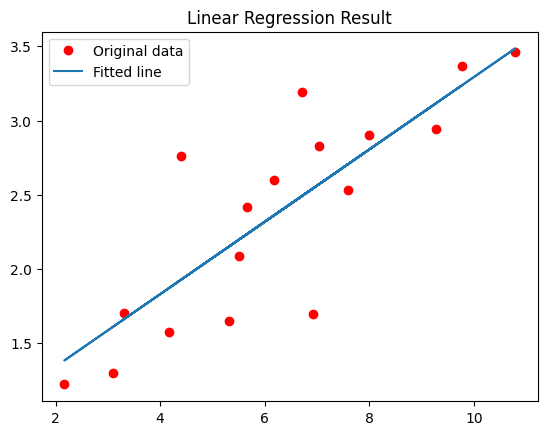

In [19]:
plt.title('Linear Regression Result')
plt.plot(X, Y, 'ro', label='Original data')
plt.plot(X, np.array(W * X+b), label= 'Fitted line')
plt.legend()
plt.show()

# Lab Logbook requirements:
### Please make sure to document the following in your Lablogbook:

Include an image of the generated graph depicting the original data and the fitted line for linear regression. Modify the appearance of the graph by adjusting its color or size. Copy the figure and paste it directly into your logbook. Refrain from taking a snapshot; instead, right-click and copy the graph to your lab logbook. Ensure that no code or other information is added to the logbook and that only required graph is present.  

#### Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

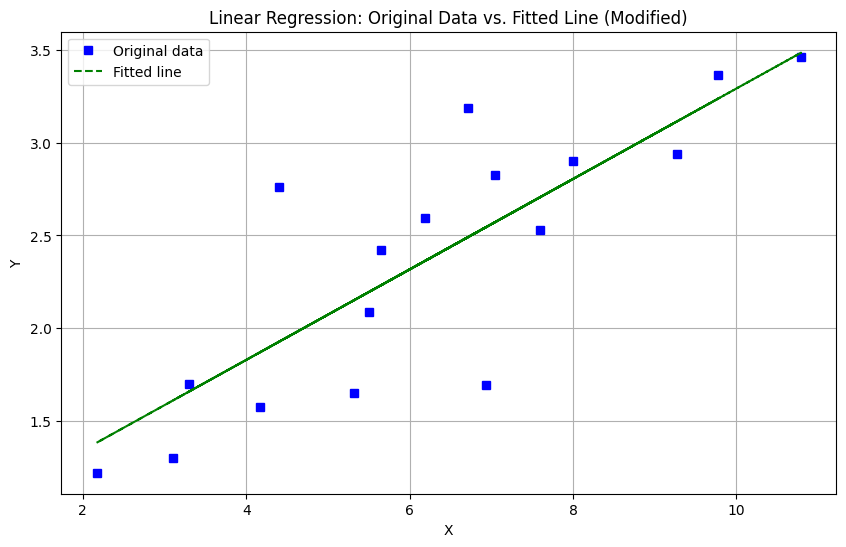

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(X, Y, 'bs', label='Original data') # 'bs' for blue squares
plt.plot(X, np.array(W * X + b), color='green', linestyle='--', label='Fitted line') # Green dashed line
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression: Original Data vs. Fitted Line (Modified)")
plt.legend()
plt.grid(True)
plt.show()